In [1]:
# Q: “Identify drivers of employee burnout in remote work environments and build a system to flag high-risk employees.”

In [2]:
import os
os.getcwd()

'/var/www/filebrowser/.projects/2cd042dd-58b5-4f2f-ab59-bda18c6bf83b/WFH_Employee_burnout'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [4]:
df = pd.read_csv("work_from_home_burnout_dataset.csv")
df.head()

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,1,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93,Low
3,1,Weekday,8.34,10.70,4,1,1,8.13,70.0,45.47,Low
4,1,Weekend,6.97,9.83,1,2,0,5.85,67.1,51.61,Low


In [5]:
df.shape

(1800, 11)

In [6]:
df.columns

Index(['user_id', 'day_type', 'work_hours', 'screen_time_hours',
       'meetings_count', 'breaks_taken', 'after_hours_work', 'sleep_hours',
       'task_completion_rate', 'burnout_score', 'burnout_risk'],
      dtype='object')

In [7]:
df.head()

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,1,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93,Low
3,1,Weekday,8.34,10.70,4,1,1,8.13,70.0,45.47,Low
4,1,Weekend,6.97,9.83,1,2,0,5.85,67.1,51.61,Low


In [8]:
df.dtypes

user_id                   int64
day_type                 object
work_hours              float64
screen_time_hours       float64
meetings_count            int64
breaks_taken              int64
after_hours_work          int64
sleep_hours             float64
task_completion_rate    float64
burnout_score           float64
burnout_risk             object
dtype: object

In [9]:
df.isnull().sum()

user_id                 0
day_type                0
work_hours              0
screen_time_hours       0
meetings_count          0
breaks_taken            0
after_hours_work        0
sleep_hours             0
task_completion_rate    0
burnout_score           0
burnout_risk            0
dtype: int64

In [10]:
df.describe()

,user_id,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,90.500000,6.515117,9.271406,1.941111,3.028889,0.358889,6.996467,72.308556,44.009978
std,51.975162,2.290521,2.409253,1.696178,1.417844,0.479808,1.061740,14.978647,23.881782
min,1.000000,3.000000,4.510000,0.000000,1.000000,0.000000,4.500000,40.000000,2.500000
25%,45.750000,4.430000,7.240000,1.000000,2.000000,0.000000,6.280000,62.300000,25.370000
50%,90.500000,6.445000,9.210000,2.000000,3.000000,0.000000,6.990000,74.500000,39.270000
75%,135.250000,8.510000,11.310000,3.000000,4.000000,1.000000,7.750000,83.700000,58.197500
max,180.000000,12.170000,15.700000,10.000000,5.000000,1.000000,10.800000,107.200000,143.920000


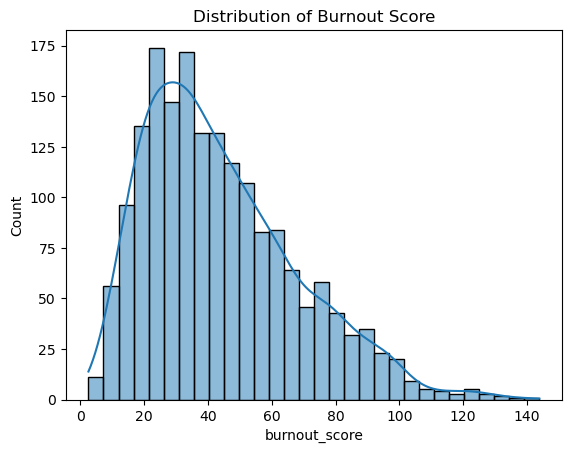

In [11]:
plt.figure()
sns.histplot(df["burnout_score"], bins=30, kde=True)
plt.title("Distribution of Burnout Score")
plt.show()

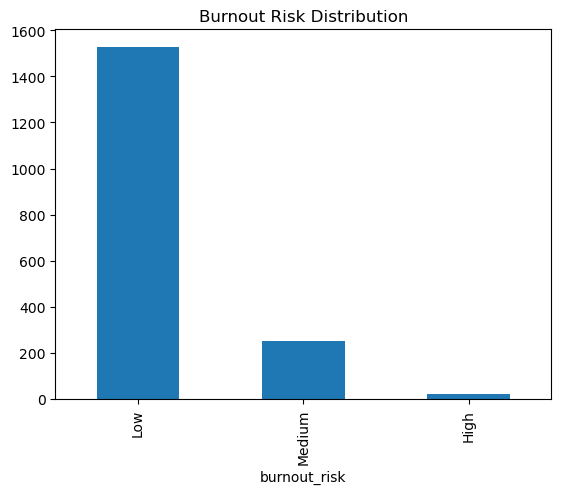

In [12]:
df["burnout_risk"].value_counts().plot(kind="bar")
plt.title("Burnout Risk Distribution")
plt.show()

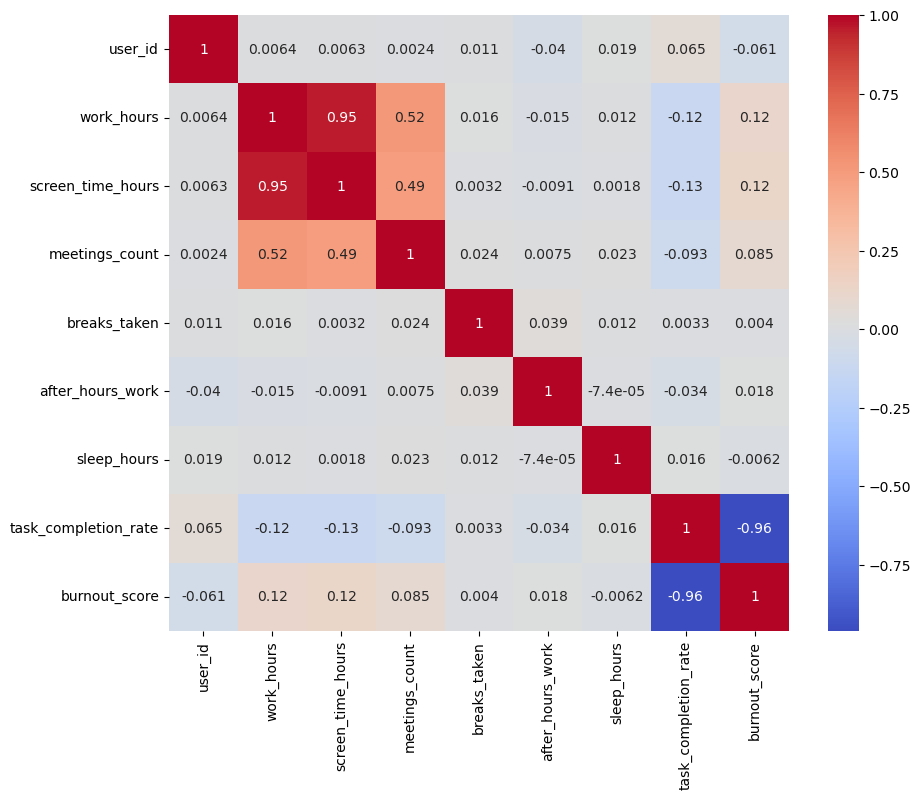

In [13]:
# correlation analysis
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [14]:
# work_hours vs burnout_score = 0.12 -> very weak positive correlation 

# sleep_hours vs burnout_score = -0.0062 -> negligible correlation, surprising! -> sleep_hours and burnout_score are 
# almost unrelated linearly in this dataset.

# after_hours_work vs burnout_score = 0.018 -> not a strong linear correlation

#Inference: 
# 1. Burnout risk is influenced by combinations of variables.
# 2. The relationships are non-linear.

In [15]:
# average burnout_score when grouped by burnout_risk
df.groupby("burnout_risk")[[
    "work_hours",
    "sleep_hours",
    "after_hours_work"
]].mean()

,work_hours,sleep_hours,after_hours_work
burnout_risk,,,
High,7.612500,7.26100,0.350000
Low,6.464885,6.99738,0.359528
Medium,6.731542,6.97004,0.355731


In [16]:
# average work_hours is ~1.1 more for high burnout_risk vs low burnout_risk

In [17]:
df.groupby("burnout_risk").mean(numeric_only=True)

,user_id,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score
burnout_risk,,,,,,,,,
High,79.950000,7.612500,10.401500,2.350000,3.300000,0.350000,7.26100,40.000000,122.571000
Low,90.977079,6.464885,9.215272,1.917485,3.028160,0.359528,6.99738,76.855272,36.340747
Medium,88.454545,6.731542,9.520870,2.051383,3.011858,0.355731,6.97004,47.420553,84.087826


In [18]:
# task_completion_rate drops significantly as burnout_risk increases. 
# Higher burnout risk is strongly associated with lower task completion.

# Burnout_risk increases as work_hours, screen_time_hours, meetings_count increase

In [19]:
df['burnout_risk'].value_counts()

burnout_risk
Low       1527
Medium     253
High        20
Name: count, dtype: int64

In [20]:
# classes are masively imbalanced with 'high' burnout_risk accounting for only ~1% of the data set
# The reason why averages are odd and weak correlations
# multi-class classification would give inaccurate results - mostly 'low' burnout_risk

In [21]:
# Create a binary column; we care about flagging the high-risk employees
df['high_risk'] = df['burnout_risk'].apply(lambda x: 1 if x == "High" else 0)

In [22]:
df['high_risk'].count()

1800

In [23]:
# Drop unnecessary columns that lead to target leaks or have no predictive value
X = df.drop(columns=['user_id', 'burnout_risk', 'burnout_score', 'high_risk'])
y = df['high_risk']

# One-hot encode categorical variable, get_dummies encodes the 'day_type' column categories 'weekday', 'weekend' into 0 or 1.
# drop_first removes a one-hot encoded column from X, to prevent multicolinearity (dummy var trap) 
X = pd.get_dummies(X, columns=['day_type'], drop_first=True)
print(X.columns)
X.head()

Index(['work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken',
       'after_hours_work', 'sleep_hours', 'task_completion_rate',
       'day_type_Weekend'],
      dtype='object')


,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,day_type_Weekend
0,9.59,11.86,4,2,0,7.55,91.2,False
1,7.38,10.33,4,1,0,6.69,82.0,True
2,6.31,8.92,1,2,0,8.87,80.6,True
3,8.34,10.70,4,1,1,8.13,70.0,False
4,6.97,9.83,1,2,0,5.85,67.1,True


In [24]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# stratification ensures there's the same proportion of high vs non-high (used when imbalanced classes)

In [25]:
X_train.count(), X_test.count()

(work_hours              1440
 screen_time_hours       1440
 meetings_count          1440
 breaks_taken            1440
 after_hours_work        1440
 sleep_hours             1440
 task_completion_rate    1440
 day_type_Weekend        1440
 dtype: int64,
 work_hours              360
 screen_time_hours       360
 meetings_count          360
 breaks_taken            360
 after_hours_work        360
 sleep_hours             360
 task_completion_rate    360
 day_type_Weekend        360
 dtype: int64)

In [26]:
# feature scaling or normalizing the values
scaler = StandardScaler()
# fit calculates mean and std. deviation of the X_train data
# transform function Applies the parameters learned from the training data, preventing data leakage.
X_train_scaled = scaler.fit_transform(X_train) # scaled data has mean = 0, std dev = 1
X_test_scaled = scaler.transform(X_test)

# feature scaling is required for logistic regression (distance-based), otherwise larger numeric features dominate 
# convergence becomes unstable

In [27]:
# 1. Logistic Regression - linear classification model P(Y=1) = 1/(1+e^-z) where z = w1x1 + w2x2 +...+ b
log_model = LogisticRegression(class_weight='balanced', random_state=42)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [28]:
y_pred_log = log_model.predict(X_test_scaled)
y_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]
# the default threshold for predict_proba() is 0.5; if threshold is increased -> less FP (model becomes stricter, needs
# higher prob in order to classify an employee high_risk) -> more FN though, recall decreases

In [29]:
print("Classification Report:")
print(classification_report(y_test, y_pred_log))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

print("ROC AUC Score:", roc_auc_score(y_test, y_proba_log))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97       356
           1       0.15      1.00      0.26         4

    accuracy                           0.94       360
   macro avg       0.57      0.97      0.61       360
weighted avg       0.99      0.94      0.96       360

Confusion Matrix:
[[333  23]
 [  0   4]]
ROC AUC Score: 0.9712078651685393


In [30]:
# TN = 333 (accurately predicted as not high risk)
# FP = 23 (predicted high risk but actually not high risk)
# FN = 0 (predicted low risk but actually high risk)
# TP = 4 (accurately predicted as high risk)

# all high-risk employees were caught by the model -> Recall for class 1 = TP / TP + FN = 1
# tradeoff = 23 employees were incorrectly flagged as high risk
# Precision = TP / TP + FP = 4 / 4+23 = 0.15 => of all the employees flagged as high-risk only 15% were actually high-risk

In [31]:
# Accuracy = TP + TN / 360 = 337/360 = 0.94
# this is misleading since 356 out of 360 values are 0s, so even blind prediction of 0 would result in high accuracy

In [32]:
# The model achieved perfect recall for high-risk employees, meaning it successfully identified all true high-risk cases. 
# However, precision was low, indicating a higher number of false positives. This tradeoff is expected in an imbalanced 
# datasets and reflects a recall-prioritized optimization strategy.

In [33]:
# 2. Random Forest Model - uses multiple decision trees, random subset of data and features, no overfitting
# captures multiple feature interactions & non-linear thresholds
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)


In [34]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [35]:
# predict() predicts 0 or 1 as value
y_pred_rf = rf_model.predict(X_test)
# prob of belonging to class 1
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

In [36]:
np.unique(y_pred_rf, return_counts=True)

(array([0]), array([360]))

In [37]:
print(classification_report(y_test, y_pred_rf, zero_division=0))
print(confusion_matrix(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       356
           1       0.00      0.00      0.00         4

    accuracy                           0.99       360
   macro avg       0.49      0.50      0.50       360
weighted avg       0.98      0.99      0.98       360

[[356   0]
 [  4   0]]
ROC AUC: 0.9515449438202246


In [38]:
# none of the values predicted were correctly classified as high_risk i.e. TP = 0, FP = 0

In [39]:
# Due to severe class imbalance (High risk employees = 1% of dataset), the baseline Random Forest failed to predict minority 
# cases. To address this, I used class weighting to penalize misclassification of high-risk employees more heavily.